# Sediment Source Modeling with McCaffrey-Style Deconvolution

**AUTHOR**  
Rodrigo Kang

## Overview

This notebook implements a McCaffrey-style deterministic deconvolution workflow for the **Sediment Source Modeling** project.

The goal is to estimate the source fractions of artificial sediment mixtures using constrained least squares. The workflow is intentionally separated from the stochastic sediment fingerprinting notebook so that the McCaffrey-style approach can be evaluated as an independent baseline.

Unlike probabilistic source apportionment models, this method produces point estimates only. Its value is therefore comparative: it shows how far a classical constrained least-squares mixture model can go before uncertainty modelling becomes necessary.

## Imports and Configuration

Paths and settings are centralised here. With the expected project layout, the notebook runs from the `python` directory, reads the project data from the sibling `data` directory, and stores all generated tables, figures, and evaluation results in the project-specific output directory:

`python/2-sediment-source-modeling-mccaffrey`

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize


# Paths

notebook_dir = Path.cwd()
project_root = notebook_dir.parent if notebook_dir.name == "python" else notebook_dir

data_dir = project_root / "data"
input_processed_dir = data_dir / "processed"

output_dir = project_root / "python" / "2-sediment-source-modeling-mccaffrey"
figures_dir = output_dir / "figures"
tables_dir = output_dir / "tables"

for directory in [output_dir, figures_dir, tables_dir]:
    directory.mkdir(parents=True, exist_ok=True)


# Project settings

source_order = ["Subsurface", "Decontaminated", "Cropland", "Forest"]

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

## Data Loading

The notebook uses the sediment fingerprinting data from the main project:

- **`mixture_proportions.csv`**: known source proportions for the artificial mixtures.
- **`fingerprint_data.csv`**: geochemical and colour fingerprint measurements for source samples and laboratory mixtures.
- **`selected_tracers.csv`**: tracer variables selected for source apportionment.

When raw files are available, the notebook reads them directly and applies the required log transformation internally. If the raw files are not available, it can read the already log-transformed input files from `data/processed`, but it does not write anything back to that directory.

In [2]:
def load_sediment_data(
    data_dir: Path,
    input_processed_dir: Path,
    source_order: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, list[str]]:
    """
    Load source signatures, mixture signatures, known proportions, and tracer names.

    Brief explanation:
    Prefer the raw project files when available. If they are not present, fall
    back to previously prepared log-transformed files. The function only reads
    from the input directories; all outputs from this notebook are written to
    the McCaffrey-specific output folder.

    Inputs:
    data_dir : Path
        Directory containing the raw project CSV files.
    input_processed_dir : Path
        Directory containing previously prepared input CSV files.
    source_order : list[str]
        Ordered source names used throughout the analysis.

    Outputs:
    tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, list[str]]
        Source data, mixture data, true proportions, and selected tracer names.

    Author:
    Rodrigo Kang
    """
    raw_files_exist = all([
        (data_dir / "mixture_proportions.csv").exists(),
        (data_dir / "fingerprint_data.csv").exists(),
        (data_dir / "selected_tracers.csv").exists(),
    ])

    if raw_files_exist:
        proportions_raw = pd.read_csv(data_dir / "mixture_proportions.csv")
        fingerprints = pd.read_csv(data_dir / "fingerprint_data.csv")
        selected_tracers = pd.read_csv(data_dir / "selected_tracers.csv")["x"].tolist()

        source_name_map = {
            "source_s": "Subsurface",
            "source_d": "Decontaminated",
            "source_pf": "Cropland",
            "source_f": "Forest",
        }

        proportions = proportions_raw.rename(columns={
            "sediment_sample": "sample",
            "source_S": "Subsurface",
            "source_D": "Decontaminated",
            "source_PF": "Cropland",
            "source_F": "Forest",
        })
        proportions[source_order] = proportions[source_order].astype(float)

        sources = fingerprints.query("type == 'source'").copy()
        targets = fingerprints.query("type == 'target'").copy()

        sources["source_label"] = sources["source"].str.lower().map(source_name_map)

        if (fingerprints[selected_tracers] <= 0).any().any():
            raise ValueError("Selected tracers must be positive before log transformation.")

        source_log_df = sources[["sample", "source", "source_label"] + selected_tracers].copy()
        target_log_df = targets[["sample"] + selected_tracers].copy()

        source_log_df[selected_tracers] = np.log(source_log_df[selected_tracers])
        target_log_df[selected_tracers] = np.log(target_log_df[selected_tracers])

        truth = pd.concat([
            targets[["sample"]].reset_index(drop=True),
            proportions[source_order].reset_index(drop=True),
        ], axis=1)

    else:
        required_files = [
            input_processed_dir / "source_log_data.csv",
            input_processed_dir / "laboratory_mixture_log_data.csv",
            input_processed_dir / "known_source_proportions.csv",
        ]

        missing_files = [path.name for path in required_files if not path.exists()]
        if missing_files:
            raise FileNotFoundError(
                "Could not find raw input files or prepared log-transformed inputs. "
                f"Missing files: {missing_files}"
            )

        source_log_df = pd.read_csv(input_processed_dir / "source_log_data.csv")
        target_log_df = pd.read_csv(input_processed_dir / "laboratory_mixture_log_data.csv")
        truth = pd.read_csv(input_processed_dir / "known_source_proportions.csv")
        selected_tracers = [
            column for column in target_log_df.columns
            if column != "sample"
        ]

    return source_log_df, target_log_df, truth, selected_tracers


source_log_df, target_log_df, truth, selected_tracers = load_sediment_data(
    data_dir=data_dir,
    input_processed_dir=input_processed_dir,
    source_order=source_order,
)

print(f"Source samples: {source_log_df.shape[0]}")
print(f"Laboratory mixtures: {target_log_df.shape[0]}")
print(f"Selected tracers: {len(selected_tracers)}")

Source samples: 70
Laboratory mixtures: 79
Selected tracers: 9


## McCaffrey-Style Preprocessing

The McCaffrey-style workflow treats sediment source apportionment as a linear deconvolution problem. Each source is represented by a single characteristic signature, computed here as the mean of the selected tracers for each source class.

The selected tracers are analysed in log-transformed space. A tracer-wise scaling step is then applied before deconvolution: each tracer is divided by the largest absolute representative source value for that tracer. This mirrors the row-wise normalization used in classical endmember deconvolution, where variables are scaled relative to endmember intensities. The same transformation is applied to both source signatures and mixture signatures.

In [3]:
# Source-level representative signatures

source_means = (
    source_log_df
    .groupby("source_label")[selected_tracers]
    .mean()
    .reindex(source_order)
)

if source_means.isna().any().any():
    raise ValueError("Some source labels are missing from the source signature matrix.")

# Tracer-wise McCaffrey-style scaling

tracer_scale = source_means.abs().max(axis=0).replace(0, np.nan)

source_signature = source_means.divide(tracer_scale, axis=1)

target_signature = target_log_df.copy()
target_signature[selected_tracers] = target_signature[selected_tracers].divide(
    tracer_scale,
    axis=1,
)

source_signature.to_csv(tables_dir / "mccaffrey_source_representative_signatures.csv")
pd.DataFrame({"tracer": tracer_scale.index, "scale": tracer_scale.values}).to_csv(
    tables_dir / "mccaffrey_tracer_scaling_factors.csv",
    index=False,
)

source_signature

,L,h,Si,Zn,Mn,K,Ti,y,C_star
source_label,,,,,,,,,
Subsurface,1.000000,0.992219,0.996496,0.964346,0.916900,0.980374,0.954174,-0.961087,1.000000
Decontaminated,0.974485,0.999926,0.998043,0.993068,1.000000,1.000000,1.000000,-0.977388,0.920883
Cropland,0.921574,1.000000,1.000000,0.999815,0.952416,0.991012,0.994349,-0.995383,0.825889
Forest,0.859933,0.982849,0.983686,1.000000,0.986032,0.948318,0.983748,-1.000000,0.785139


## Constrained Least-Squares Deconvolution

For each artificial mixture, the source fractions are estimated by solving a constrained least-squares problem:

$$
\min_x \lVert Ax - b \rVert^2
$$

subject to:

$$
x_k \geq 0, \qquad \sum_k x_k = 1
$$

where $A$ contains the representative source signatures, $b$ is the mixture signature, and $x$ is the vector of estimated source fractions.

In [4]:
def estimate_mccaffrey_fractions(
    source_matrix: np.ndarray,
    target_vector: np.ndarray,
) -> tuple[np.ndarray, float, np.ndarray]:
    """
    Estimate source fractions using constrained least squares.

    Brief explanation:
    Solve a McCaffrey-style mixture deconvolution problem with non-negative
    source fractions constrained to sum to one.

    Inputs:
    source_matrix : np.ndarray
        Matrix with tracers in rows and sources in columns.
    target_vector : np.ndarray
        Mixture tracer vector.

    Outputs:
    tuple[np.ndarray, float, np.ndarray]
        Estimated fractions, residual sum of squares, and predicted mixture vector.

    Author:
    Rodrigo Kang
    """
    n_sources = source_matrix.shape[1]
    x0 = np.full(n_sources, 1.0 / n_sources)

    def objective(fractions: np.ndarray) -> float:
        residual = source_matrix @ fractions - target_vector
        return float(residual @ residual)

    constraints = {
        "type": "eq",
        "fun": lambda fractions: np.sum(fractions) - 1.0,
    }

    bounds = [(0.0, 1.0)] * n_sources

    result = minimize(
        objective,
        x0=x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 1000, "ftol": 1e-12},
    )

    if not result.success:
        raise RuntimeError(f"McCaffrey optimisation failed: {result.message}")

    fractions = np.clip(result.x, 0.0, 1.0)
    fractions = fractions / fractions.sum()

    predicted = source_matrix @ fractions
    rss = float((predicted - target_vector) @ (predicted - target_vector))

    return fractions, rss, predicted


A = source_signature[selected_tracers].T.to_numpy()

records = []
residual_records = []

truth_lookup = truth.set_index("sample")[source_order]

for _, row in target_signature.iterrows():
    sample = row["sample"]
    b = row[selected_tracers].to_numpy(dtype=float)
    fractions, rss, predicted = estimate_mccaffrey_fractions(A, b)

    for source, value in zip(source_order, fractions):
        records.append({
            "sample": sample,
            "source_label": source,
            "estimated_proportion": value,
            "true_proportion": truth_lookup.loc[sample, source],
            "rss": rss,
        })

    residual_records.extend([
        {
            "sample": sample,
            "tracer": tracer,
            "observed": observed,
            "predicted": pred,
            "residual": observed - pred,
        }
        for tracer, observed, pred in zip(selected_tracers, b, predicted)
    ])

mccaffrey_results = pd.DataFrame(records)
residuals = pd.DataFrame(residual_records)

mccaffrey_results.to_csv(
    tables_dir / "mccaffrey_source_apportionment.csv",
    index=False,
)

residuals.to_csv(
    tables_dir / "mccaffrey_residuals_by_tracer.csv",
    index=False,
)

mccaffrey_results.head()

,sample,source_label,estimated_proportion,true_proportion,rss
0,mel1,Subsurface,9.161598e-01,1.0,0.000564
1,mel1,Decontaminated,8.384015e-02,0.0,0.000564
2,mel1,Cropland,0.000000e+00,0.0,0.000564
3,mel1,Forest,1.734723e-18,0.0,0.000564
4,mel2,Subsurface,2.118915e-01,0.0,0.000164


## Model Evaluation

Because the McCaffrey-style model is deterministic, the evaluation focuses on point-estimate accuracy rather than uncertainty calibration. The main metrics are mean absolute error, root mean squared error, mean error, Nash-Sutcliffe Efficiency, Aitchison distance, and dominant-source classification accuracy.

Because sediment source apportionment estimates are compositional data constrained to the simplex, the Aitchison distance is also reported as a composition-aware performance metric. The source-level metrics are especially useful because they reveal whether the deterministic baseline systematically overestimates or underestimates a particular source class.

In [5]:
def nash_sutcliffe_efficiency(observed: np.ndarray, predicted: np.ndarray) -> float:
    """
    Compute Nash-Sutcliffe Efficiency.

    Brief explanation:
    Compare prediction errors against the variance of the observed values.

    Inputs:
    observed : np.ndarray
        Observed values.
    predicted : np.ndarray
        Predicted values.

    Outputs:
    float
        Nash-Sutcliffe Efficiency.

    Author:
    Rodrigo Kang
    """
    numerator = np.sum((observed - predicted) ** 2)
    denominator = np.sum((observed - observed.mean()) ** 2)
    return float(1 - numerator / denominator)


def aitchison_distance(x: Iterable[float], y: Iterable[float], eps: float = 1e-12) -> float:
    """
    Compute Aitchison distance between two compositions.

    Brief explanation:
    Apply the centered log-ratio transform and compute the Euclidean distance
    between transformed compositions.

    Inputs:
    x : Iterable[float]
        First compositional vector.
    y : Iterable[float]
        Second compositional vector.
    eps : float
        Small value used to avoid log-zero issues.

    Outputs:
    float
        Aitchison distance.

    Author:
    Rodrigo Kang
    """
    x = np.clip(np.asarray(x, dtype=float), eps, None)
    y = np.clip(np.asarray(y, dtype=float), eps, None)

    x = x / x.sum()
    y = y / y.sum()

    clr_x = np.log(x) - np.mean(np.log(x))
    clr_y = np.log(y) - np.mean(np.log(y))

    return float(np.linalg.norm(clr_x - clr_y))


y_true = mccaffrey_results["true_proportion"].to_numpy()
y_pred = mccaffrey_results["estimated_proportion"].to_numpy()

predicted_wide = (
    mccaffrey_results
    .pivot(index="sample", columns="source_label", values="estimated_proportion")
    .reindex(columns=source_order)
)

truth_wide = truth.set_index("sample").reindex(predicted_wide.index)[source_order]

dominant_true = truth_wide.idxmax(axis=1)
dominant_pred = predicted_wide.idxmax(axis=1)

sample_metrics = pd.DataFrame({
    "sample": predicted_wide.index,
    "dominant_true": dominant_true.values,
    "dominant_pred": dominant_pred.values,
    "dominant_correct": (dominant_true == dominant_pred).values,
    "aitchison_distance": [
        aitchison_distance(truth_wide.loc[sample], predicted_wide.loc[sample])
        for sample in predicted_wide.index
    ],
    "mean_absolute_error": [
        np.mean(np.abs(truth_wide.loc[sample].to_numpy() - predicted_wide.loc[sample].to_numpy()))
        for sample in predicted_wide.index
    ],
})

metrics = pd.DataFrame([
    {
        "model": "McCaffrey constrained least squares",
        "mae": np.mean(np.abs(y_true - y_pred)),
        "rmse": np.sqrt(np.mean((y_true - y_pred) ** 2)),
        "mean_error": np.mean(y_pred - y_true),
        "nse": nash_sutcliffe_efficiency(y_true, y_pred),
        "dominant_source_accuracy": (dominant_true == dominant_pred).mean(),
        "mean_aitchison_distance": sample_metrics["aitchison_distance"].mean(),
    }
])

source_metrics = (
    mccaffrey_results
    .assign(
        absolute_error=lambda df: (df["estimated_proportion"] - df["true_proportion"]).abs(),
        squared_error=lambda df: (df["estimated_proportion"] - df["true_proportion"]) ** 2,
        error=lambda df: df["estimated_proportion"] - df["true_proportion"],
    )
    .groupby("source_label")
    .agg(
        mae=("absolute_error", "mean"),
        rmse=("squared_error", lambda x: np.sqrt(np.mean(x))),
        mean_error=("error", "mean"),
    )
    .reindex(source_order)
    .reset_index()
)

dominant_confusion = pd.crosstab(
    dominant_true,
    dominant_pred,
    rownames=["Known dominant source"],
    colnames=["Estimated dominant source"],
).reindex(index=source_order, columns=source_order, fill_value=0)

metrics.to_csv(tables_dir / "mccaffrey_model_evaluation_metrics.csv", index=False)
source_metrics.to_csv(tables_dir / "mccaffrey_source_level_metrics.csv", index=False)
sample_metrics.to_csv(tables_dir / "mccaffrey_sample_level_metrics.csv", index=False)
dominant_confusion.to_csv(tables_dir / "mccaffrey_dominant_source_confusion_matrix.csv")

metrics.round(4)

,model,mae,rmse,mean_error,nse,dominant_source_accuracy,mean_aitchison_distance
0,McCaffrey constrained least squares,0.0793,0.1086,0.0,0.8683,0.8354,16.6797


In [6]:
source_metrics.round(4)

,source_label,mae,rmse,mean_error
0,Subsurface,0.0768,0.1037,-0.0601
1,Decontaminated,0.1234,0.1517,0.1106
2,Cropland,0.0693,0.0975,-0.0532
3,Forest,0.0478,0.0625,0.0028


## Visual Diagnostics

The following figures summarise the deterministic source apportionment results. They compare estimated and known source fractions, show a small set of representative mixtures, inspect source-level error patterns, and evaluate residual structure across tracers.

The goal is not only to report accuracy, but also to identify where the deterministic approximation works well and where source variability may be affecting the estimates.

### Overall Performance Summary

The first diagnostic summarises the main benchmark metrics in a compact form. MAE and RMSE describe point-estimate error, NSE measures overall predictive skill, and dominant-source accuracy evaluates whether the method correctly identifies the largest contributing source in each mixture.

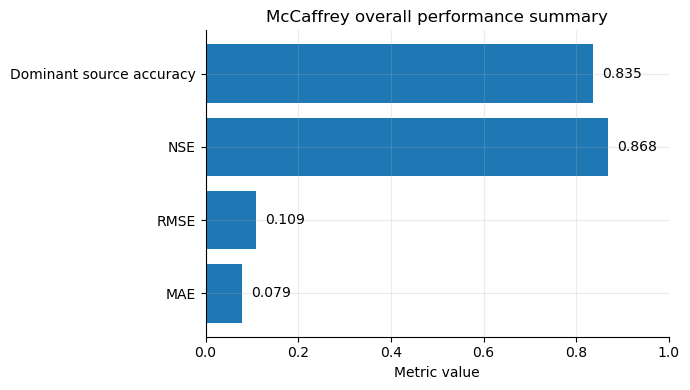

In [7]:
# Overall performance summary

performance_summary = pd.DataFrame({
    "metric": [
        "MAE",
        "RMSE",
        "NSE",
        "Dominant source accuracy",
    ],
    "value": [
        metrics.loc[0, "mae"],
        metrics.loc[0, "rmse"],
        metrics.loc[0, "nse"],
        metrics.loc[0, "dominant_source_accuracy"],
    ],
})

fig, ax = plt.subplots(figsize=(7, 4))

ax.barh(performance_summary["metric"], performance_summary["value"])
ax.set_xlabel("Metric value")
ax.set_title("McCaffrey overall performance summary")
ax.set_xlim(0, 1)

for index, value in enumerate(performance_summary["value"]):
    ax.text(value + 0.02, index, f"{value:.3f}", va="center")

fig.tight_layout()
fig.savefig(figures_dir / "mccaffrey_overall_performance_summary.png", dpi=180)
plt.show()

performance_summary.to_csv(
    tables_dir / "mccaffrey_overall_performance_summary.csv",
    index=False,
)

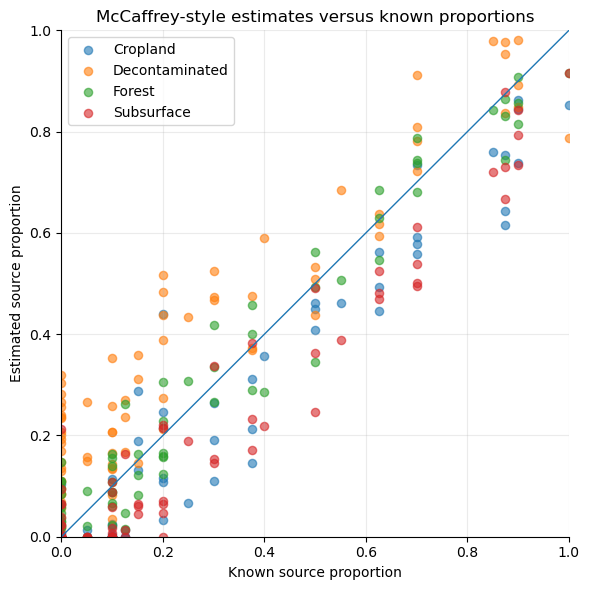

In [8]:
# Estimated versus true source proportions

fig, ax = plt.subplots(figsize=(6, 6))

for source, group in mccaffrey_results.groupby("source_label"):
    ax.scatter(
        group["true_proportion"],
        group["estimated_proportion"],
        alpha=0.6,
        s=35,
        label=source,
    )

ax.plot([0, 1], [0, 1], linewidth=1)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Known source proportion")
ax.set_ylabel("Estimated source proportion")
ax.set_title("McCaffrey-style estimates versus known proportions")
ax.legend()

fig.tight_layout()
fig.savefig(figures_dir / "mccaffrey_estimated_vs_true.png", dpi=180)
plt.show()

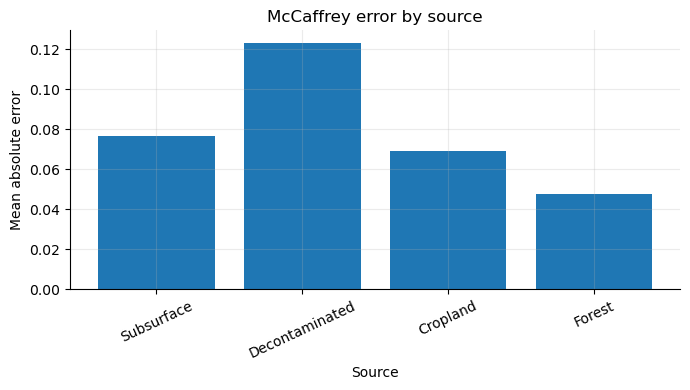

In [9]:
# Source-level mean absolute error

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(source_metrics["source_label"], source_metrics["mae"])
ax.set_xlabel("Source")
ax.set_ylabel("Mean absolute error")
ax.set_title("McCaffrey error by source")
ax.tick_params(axis="x", rotation=25)

fig.tight_layout()
fig.savefig(figures_dir / "mccaffrey_error_by_source.png", dpi=180)
plt.show()

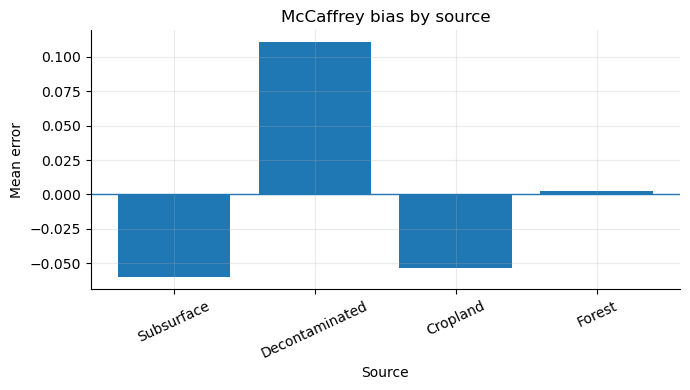

In [10]:
# Source-level mean error

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(source_metrics["source_label"], source_metrics["mean_error"])
ax.axhline(0, linewidth=1)
ax.set_xlabel("Source")
ax.set_ylabel("Mean error")
ax.set_title("McCaffrey bias by source")
ax.tick_params(axis="x", rotation=25)

fig.tight_layout()
fig.savefig(figures_dir / "mccaffrey_bias_by_source.png", dpi=180)
plt.show()

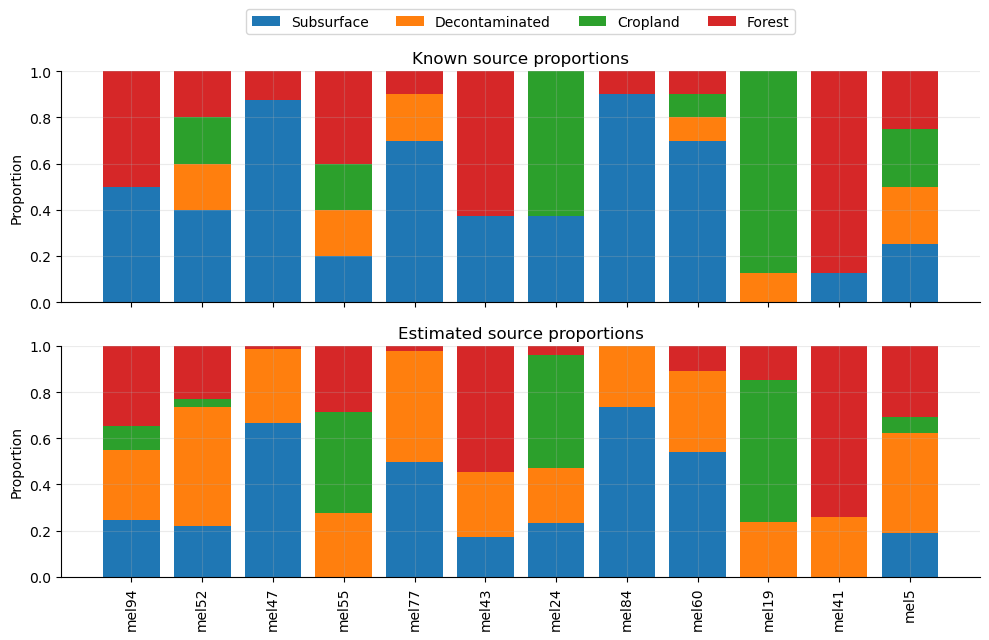

In [11]:
# Known and estimated compositions for representative mixtures

n_examples = min(12, len(predicted_wide))

example_samples = (
    sample_metrics
    .sort_values("mean_absolute_error", ascending=False)
    .head(n_examples)["sample"]
    .tolist()
)

comparison_long = []

for sample in example_samples:
    for source in source_order:
        comparison_long.append({
            "sample": sample,
            "source_label": source,
            "type": "Known",
            "proportion": truth_wide.loc[sample, source],
        })
        comparison_long.append({
            "sample": sample,
            "source_label": source,
            "type": "Estimated",
            "proportion": predicted_wide.loc[sample, source],
        })

comparison_long = pd.DataFrame(comparison_long)

fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True)

for ax, label in zip(axes, ["Known", "Estimated"]):
    bottom = np.zeros(n_examples)
    data = (
        comparison_long
        .query("type == @label")
        .pivot(index="sample", columns="source_label", values="proportion")
        .reindex(index=example_samples, columns=source_order)
    )

    for source in source_order:
        ax.bar(np.arange(n_examples), data[source], bottom=bottom, label=source)
        bottom += data[source].to_numpy()

    ax.set_ylim(0, 1)
    ax.set_ylabel("Proportion")
    ax.set_title(f"{label} source proportions")

axes[-1].set_xticks(np.arange(n_examples), labels=example_samples, rotation=90)
axes[0].legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1.3))

fig.tight_layout()
fig.savefig(figures_dir / "mccaffrey_known_vs_estimated_representative_compositions.png", dpi=180)
plt.show()

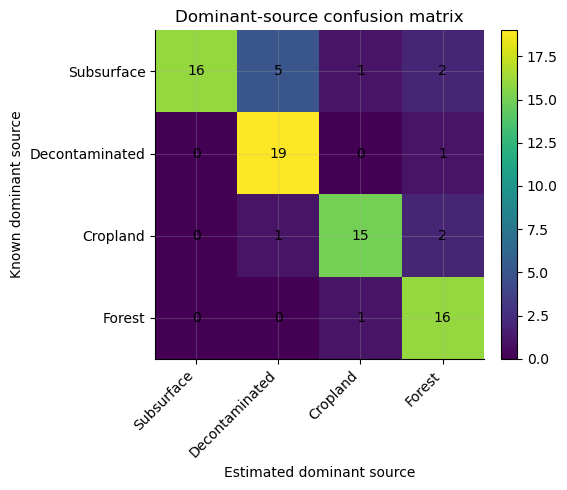

In [12]:
# Dominant-source confusion matrix

fig, ax = plt.subplots(figsize=(6, 5))

image = ax.imshow(dominant_confusion.to_numpy())

ax.set_xticks(np.arange(len(source_order)), labels=source_order, rotation=45, ha="right")
ax.set_yticks(np.arange(len(source_order)), labels=source_order)
ax.set_xlabel("Estimated dominant source")
ax.set_ylabel("Known dominant source")
ax.set_title("Dominant-source confusion matrix")

for i in range(dominant_confusion.shape[0]):
    for j in range(dominant_confusion.shape[1]):
        ax.text(
            j,
            i,
            int(dominant_confusion.iloc[i, j]),
            ha="center",
            va="center",
        )

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
fig.savefig(figures_dir / "mccaffrey_dominant_source_confusion_matrix.png", dpi=180)
plt.show()

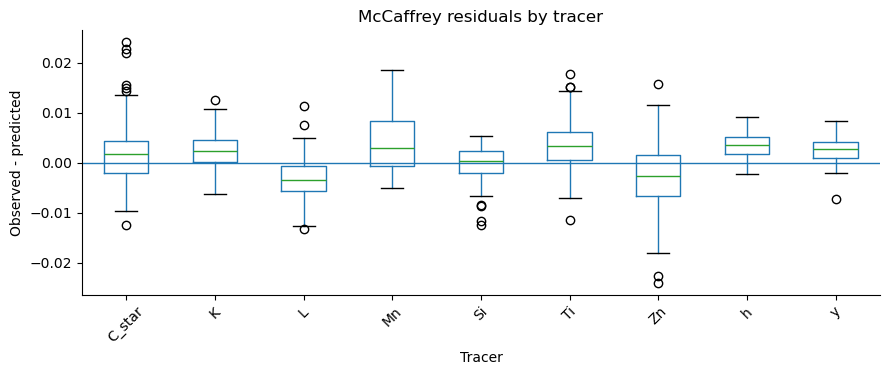

In [13]:
# Residuals by tracer

fig, ax = plt.subplots(figsize=(9, 4))

residuals.boxplot(
    column="residual",
    by="tracer",
    ax=ax,
    grid=False,
    rot=45,
)

ax.axhline(0, linewidth=1)
ax.set_title("McCaffrey residuals by tracer")
ax.set_xlabel("Tracer")
ax.set_ylabel("Observed - predicted")
fig.suptitle("")

fig.tight_layout()
fig.savefig(figures_dir / "mccaffrey_residuals_by_tracer.png", dpi=180)
plt.show()

## Interpretation

Despite its simplicity, the constrained least-squares formulation provides accurate source proportion estimates when the selected fingerprint tracers separate the source classes reasonably well. This suggests that much of the predictive performance can be explained by the strong separability of the selected tracer space.

The method is especially useful as a diagnostic baseline. A good overall fit indicates that the sediment mixing problem is well conditioned, while source-level errors reveal where the deterministic approximation is less reliable. A source with consistently positive mean error is being overestimated, whereas a source with consistently negative mean error is being underestimated. This can indicate overlap between source signatures or cases where a single mean signature is not sufficient to represent within-source variability.

The residual diagnostics provide an additional tracer-level check. If residuals are centred around zero and no tracer shows a strong systematic bias, the deterministic approximation is not being driven by one problematic variable. If some tracers show large or asymmetric residuals, they may be disproportionately influencing the estimated source fractions.

## Final Remarks

The McCaffrey-style workflow is best understood as a classical constrained least-squares baseline for sediment source apportionment. It is compact, transparent, and easy to interpret.

Its main limitation is that source variability is compressed into a single representative signature for each source class. As a result, the method does not produce uncertainty intervals and cannot assess calibration in the same way as stochastic sediment fingerprinting models.

For this portfolio project, that limitation is also useful. The notebook shows how much can be achieved with a deterministic deconvolution approach, while also clarifying why probabilistic methods remain necessary when uncertainty, interval coverage, and source variability are central to the scientific question.